# 04 — Feature Engineering

Este notebook implementa y compara nuevas variables sustentadas en las hipótesis de Feature Analysis. La primera iteración utiliza Logistic Regression como instrumento de comparación controlada: se mantienen fijos el modelo, sus hiperparámetros, los folds y los grupos del baseline.

## Protocolo experimental

- Desarrollo: reservas de 2015–2016.
- Holdout temporal: enero–agosto de 2017. Se separa, pero no se consulta durante la selección de features.
- Validación interna: cinco folds de `StratifiedGroupKFold`.
- Grupos: combinaciones exactas del conjunto base, idénticas para todos los experimentos.
- Modelo fijo: Logistic Regression con `C=10` y `class_weight='balanced'`.
- Métrica principal: ROC AUC medio y desviación entre folds.

Las transformaciones de esta etapa son determinísticas y se calculan por fila: no aprenden estadísticas del target ni del dataset completo. La imputación, codificación y escala permanecen dentro del pipeline.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)

# Control de los bloques de entrenamiento. Los diagnósticos y la construcción de variables
# se ejecutan siempre; estas banderas deciden qué comparaciones usan validación cruzada.
RUN_FIRST_BATCH_COMPARISON = False
RUN_FIRST_BATCH_ABLATION = False
RUN_SECOND_BATCH_EXPERIMENTS = True
RUN_SECOND_BATCH_COMBINED_EXPERIMENT = True

In [2]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "src").is_dir():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz local del proyecto.")

project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.association import (
    build_focused_association_table,
    calculate_numeric_vif,
)
from src.config import RANDOM_STATE, RAW_DATA_DIR
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.evaluation import (
    cross_validate_model,
    get_stratified_group_cross_validation,
)
from src.features import (
    add_cyclic_day_of_week_features,
    add_cyclic_month_features,
    add_domestic_indicator,
    add_lead_time_band_feature,
    add_log_lead_time_feature,
    add_parking_indicator,
    add_previous_cancellation_indicator,
    add_previous_cancellation_rate,
    add_profile_indicator_features,
    add_stay_composition_features,
    add_special_request_indicator,
    add_waiting_list_indicator,
    add_waiting_list_interaction_features,
    build_base_feature_set,
    build_first_engineered_feature_set,
    build_logistic_first_batch_candidate_set,
    build_logistic_redundant_first_batch_set,
    build_second_batch_diagnostic_set,
    get_feature_types,
    LOGISTIC_REGRESSION_FIRST_BATCH_EXCLUSIONS,
    make_exact_feature_groups,
    remove_redundant_base_features,
)
from src.preprocessing import build_tabular_preprocessor

## Carga y conjunto base

In [4]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = normalize_text_values(combine_hotel_datasets(h1_df, h2_df))
X_baseline_reference, y = build_base_feature_set(bookings_df)
X_base = remove_redundant_base_features(X_baseline_reference)

print(f"Dataset: {len(X_base):,} filas")
print(f"Baseline histórico: {X_baseline_reference.shape[1]} features")
print(f"Base depurada: {X_base.shape[1]} features")

Dataset: 119,390 filas
Baseline histórico: 25 features
Base depurada: 24 features


In [5]:
X_train_reference, X_holdout_reference, y_train, y_holdout = make_temporal_holdout_split(
    X_baseline_reference, y, X_baseline_reference["ArrivalDateYear"], validation_period=2017
)
X_train_base = remove_redundant_base_features(X_train_reference)
X_holdout_base = remove_redundant_base_features(X_holdout_reference)
base_groups = make_exact_feature_groups(X_train_reference)

split_summary = pd.DataFrame({
    "subset": ["Development 2015-2016", "Reserved holdout 2017 Jan-Aug"],
    "rows": [len(X_train_base), len(X_holdout_base)],
    "cancellation_rate": [y_train.mean(), y_holdout.mean()],
})
display(split_summary.round(4))
print(f"Grupos exactos en desarrollo: {base_groups.nunique():,}")

,subset,rows,cancellation_rate
0,Development 2015-2016,78703,0.3619
1,Reserved holdout 2017 Jan-Aug,40687,0.3870


Grupos exactos en desarrollo: 52,930


# Primer lote de features

## Composición de la reserva

- `TotalGuests = Adults + Children + Babies`.
- `TotalNights = StaysInWeekendNights + StaysInWeekNights`.

Estas sumas aportan una representación directa del tamaño de la reserva y de la duración total, sin reemplazar inicialmente sus componentes.

## Indicadores de perfil e historial

- `IsDomestic`: identifica reservas cuyo país es Portugal (`PRT`).
- `WasOnWaitingList`: separa el cero estructural de los tiempos positivos.
- `HasPreviousCancellation`: distingue clientes con cancelaciones anteriores.
- `PreviousCancellationRate`: cancelaciones anteriores sobre el total de reservas históricas conocidas; vale cero cuando no existe historial.

`IsDomestic` no utiliza el target ni agrupaciones aprendidas. Cuando `Country` es nulo, el indicador también permanece nulo y se imputa dentro del pipeline. La categoría `Country` original se conserva para comprobar si el indicador agrega una representación útil o resulta redundante.

## Interacción de lista de espera y hotel

Feature Analysis mostró que la relación de `DaysInWaitingList` cambia de dirección entre City Hotel y Resort Hotel. `CityHotelWasOnWaitingList` permite que Logistic Regression represente efectos diferentes según el hotel, en lugar de imponer un único coeficiente común.

In [6]:
feature_sets = {
    "Historical baseline": X_train_reference.copy(),
    "Cleaned base": X_train_base.copy(),
    "Stay composition": add_stay_composition_features(X_train_base),
    "Profile and history indicators": add_profile_indicator_features(X_train_base),
    "Waiting-list interaction": add_waiting_list_interaction_features(X_train_base),
    "Complete first batch": build_first_engineered_feature_set(X_train_base),
}

historical_columns = set(X_train_reference.columns)
cleaned_columns = set(X_train_base.columns)
feature_set_summary = pd.DataFrame([
    {
        "feature_set": name,
        "total_features": frame.shape[1],
        "added_vs_cleaned_base": sorted(set(frame.columns).difference(cleaned_columns)),
        "removed_vs_historical": sorted(historical_columns.difference(frame.columns)),
        "missing_values": int(frame.isna().sum().sum()),
    }
    for name, frame in feature_sets.items()
])
display(feature_set_summary)

,feature_set,total_features,added_vs_cleaned_base,removed_vs_historical,missing_values
0,Historical baseline,25,[ArrivalDateWeekNumber],[],409
1,Cleaned base,24,[],[ArrivalDateWeekNumber],409
2,Stay composition,26,"[TotalGuests, TotalNights]",[ArrivalDateWeekNumber],409
3,Profile and history indicators,28,"[HasPreviousCancellation, IsDomestic, Previous...",[ArrivalDateWeekNumber],814
4,Waiting-list interaction,26,"[CityHotelWasOnWaitingList, WasOnWaitingList]",[ArrivalDateWeekNumber],409
5,Complete first batch,31,"[CityHotelWasOnWaitingList, HasPreviousCancell...",[ArrivalDateWeekNumber],814


# Correlación y multicolinealidad del primer lote

Las siete variables nuevas se derivan de columnas existentes, por lo que se esperan asociaciones fuertes. El objetivo no es eliminar automáticamente toda redundancia, sino distinguir entre una representación alternativa que ayuda al modelo y una duplicación que sólo complica la interpretación.

In [7]:
ENGINEERED_FEATURES_FIRST_BATCH = [
    "TotalGuests", "TotalNights", "IsDomestic",
    "WasOnWaitingList", "HasPreviousCancellation",
    "PreviousCancellationRate", "CityHotelWasOnWaitingList",
]

engineered_dependency_summary = pd.DataFrame([
    {"engineered_feature": "TotalGuests", "source_features": "Adults + Children + Babies", "relationship": "Exact sum"},
    {"engineered_feature": "TotalNights", "source_features": "StaysInWeekendNights + StaysInWeekNights", "relationship": "Exact sum"},
    {"engineered_feature": "IsDomestic", "source_features": "Country == PRT", "relationship": "Deterministic indicator"},
    {"engineered_feature": "WasOnWaitingList", "source_features": "DaysInWaitingList > 0", "relationship": "Deterministic indicator"},
    {"engineered_feature": "HasPreviousCancellation", "source_features": "PreviousCancellations > 0", "relationship": "Deterministic indicator"},
    {"engineered_feature": "PreviousCancellationRate", "source_features": "PreviousCancellations / previous bookings", "relationship": "Deterministic ratio"},
    {"engineered_feature": "CityHotelWasOnWaitingList", "source_features": "HotelType × WasOnWaitingList", "relationship": "Deterministic interaction"},
])
display(engineered_dependency_summary)

,engineered_feature,source_features,relationship
0,TotalGuests,Adults + Children + Babies,Exact sum
1,TotalNights,StaysInWeekendNights + StaysInWeekNights,Exact sum
2,IsDomestic,Country == PRT,Deterministic indicator
3,WasOnWaitingList,DaysInWaitingList > 0,Deterministic indicator
4,HasPreviousCancellation,PreviousCancellations > 0,Deterministic indicator
5,PreviousCancellationRate,PreviousCancellations / previous bookings,Deterministic ratio
6,CityHotelWasOnWaitingList,HotelType × WasOnWaitingList,Deterministic interaction


## Asociación con variables originales y nuevas

Para cada feature creada se calcula Spearman absoluto frente a numéricas y razón de correlación $\eta$ frente a categóricas. La tabla está focalizada en pares que contienen al menos una variable nueva. Las categorías infrecuentes se agrupan con el mismo criterio utilizado en Feature Analysis.

In [8]:
X_first_batch = build_first_engineered_feature_set(X_train_base)
_, first_batch_categorical_features = get_feature_types(X_first_batch)
engineered_associations = build_focused_association_table(
    X=X_first_batch,
    focus_features=ENGINEERED_FEATURES_FIRST_BATCH,
    categorical_features=first_batch_categorical_features,
)

display(engineered_associations.head(30).round(4))
display(engineered_associations.loc[
    engineered_associations["association"].ge(0.70)
].round(4))

,engineered_feature,compared_feature,metric,association
0,IsDomestic,Country,Correlation ratio eta,1.0000
1,HasPreviousCancellation,PreviousCancellations,Absolute Spearman,0.9998
2,HasPreviousCancellation,PreviousCancellationRate,Absolute Spearman,0.9998
3,WasOnWaitingList,DaysInWaitingList,Absolute Spearman,0.9997
4,PreviousCancellationRate,PreviousCancellations,Absolute Spearman,0.9995
5,WasOnWaitingList,CityHotelWasOnWaitingList,Absolute Spearman,0.9718
6,CityHotelWasOnWaitingList,DaysInWaitingList,Absolute Spearman,0.9705
7,TotalGuests,Adults,Absolute Spearman,0.8899
8,TotalNights,StaysInWeekNights,Absolute Spearman,0.8613
9,TotalNights,StaysInWeekendNights,Absolute Spearman,0.6574


,engineered_feature,compared_feature,metric,association
0,IsDomestic,Country,Correlation ratio eta,1.0000
1,HasPreviousCancellation,PreviousCancellations,Absolute Spearman,0.9998
2,HasPreviousCancellation,PreviousCancellationRate,Absolute Spearman,0.9998
3,WasOnWaitingList,DaysInWaitingList,Absolute Spearman,0.9997
4,PreviousCancellationRate,PreviousCancellations,Absolute Spearman,0.9995
5,WasOnWaitingList,CityHotelWasOnWaitingList,Absolute Spearman,0.9718
6,CityHotelWasOnWaitingList,DaysInWaitingList,Absolute Spearman,0.9705
7,TotalGuests,Adults,Absolute Spearman,0.8899
8,TotalNights,StaysInWeekNights,Absolute Spearman,0.8613


## Matriz numérica focalizada

La figura incluye las features nuevas y las numéricas originales que las generan. Permite observar dirección y magnitud de las relaciones monótonas, a diferencia de la tabla mixta, que muestra sólo magnitudes.

,Adults,Children,Babies,StaysInWeekendNights,StaysInWeekNights,DaysInWaitingList,PreviousCancellations,PreviousBookingsNotCanceled,TotalGuests,TotalNights,IsDomestic,WasOnWaitingList,HasPreviousCancellation,PreviousCancellationRate,CityHotelWasOnWaitingList
Adults,1.000,0.072,0.031,0.132,0.141,-0.039,-0.019,-0.205,0.890,0.188,-0.133,-0.040,-0.018,-0.017,-0.040
Children,0.072,1.000,0.039,0.041,0.043,-0.054,-0.066,-0.032,0.483,0.052,-0.064,-0.054,-0.066,-0.066,-0.053
Babies,0.031,0.039,1.000,0.023,0.025,-0.019,-0.023,-0.012,0.172,0.029,0.006,-0.019,-0.023,-0.023,-0.019
StaysInWeekendNights,0.132,0.041,0.023,1.000,0.234,-0.092,-0.055,-0.081,0.136,0.657,-0.179,-0.092,-0.055,-0.055,-0.095
StaysInWeekNights,0.141,0.043,0.025,0.234,1.000,0.020,-0.060,-0.119,0.144,0.861,-0.157,0.019,-0.060,-0.060,0.007
DaysInWaitingList,-0.039,-0.054,-0.019,-0.092,0.020,1.000,0.106,-0.022,-0.059,-0.016,0.139,1.000,0.106,0.107,0.970
PreviousCancellations,-0.019,-0.066,-0.023,-0.055,-0.060,0.106,1.000,0.063,-0.048,-0.072,0.295,0.110,1.000,0.999,0.116
PreviousBookingsNotCanceled,-0.205,-0.032,-0.012,-0.081,-0.119,-0.022,0.063,1.000,-0.193,-0.143,0.134,-0.021,0.059,0.051,-0.021
TotalGuests,0.890,0.483,0.172,0.136,0.144,-0.059,-0.048,-0.193,1.000,0.190,-0.145,-0.060,-0.047,-0.046,-0.060
TotalNights,0.188,0.052,0.029,0.657,0.861,-0.016,-0.072,-0.143,0.190,1.000,-0.220,-0.017,-0.072,-0.071,-0.029


Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_engineering_first_batch_correlations.png


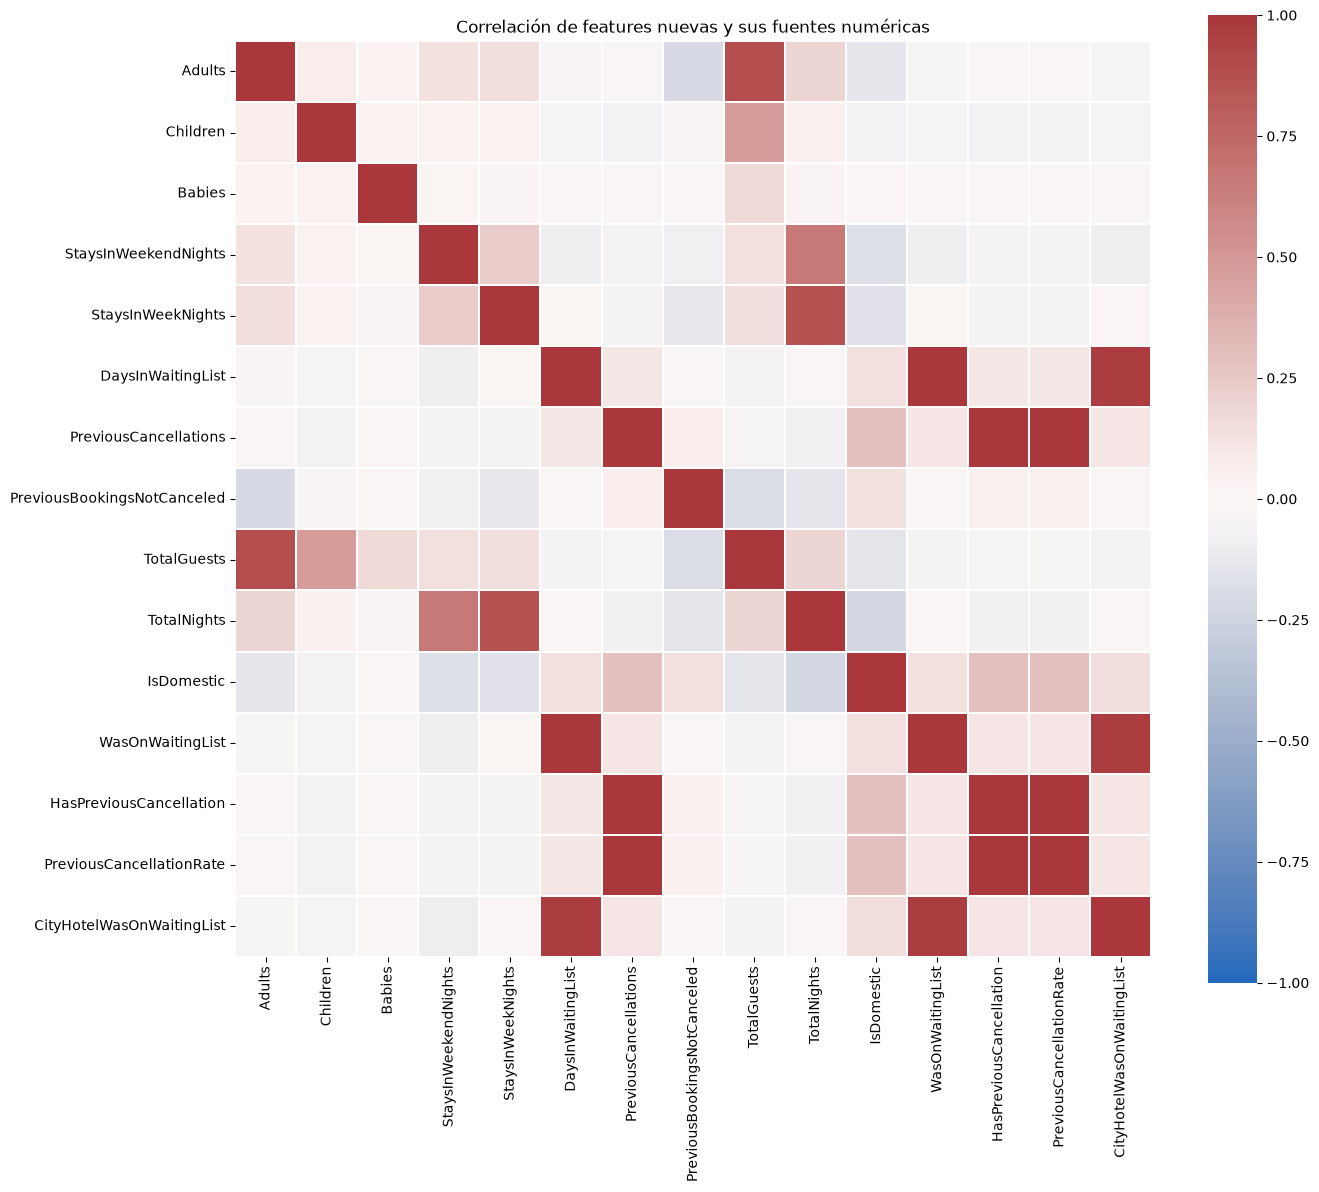

In [9]:
ENGINEERED_NUMERIC_SOURCE_FEATURES = [
    "Adults", "Children", "Babies",
    "StaysInWeekendNights", "StaysInWeekNights",
    "DaysInWaitingList", "PreviousCancellations",
    "PreviousBookingsNotCanceled",
]
focused_numeric_features = [
    *ENGINEERED_NUMERIC_SOURCE_FEATURES, *ENGINEERED_FEATURES_FIRST_BATCH
]
engineered_numeric_correlation = X_first_batch[focused_numeric_features].corr(
    method="spearman"
)
display(engineered_numeric_correlation.round(3))

figure, axis = plt.subplots(figsize=(14, 12))
sns.heatmap(
    engineered_numeric_correlation, cmap="vlag", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.3, ax=axis,
)
axis.set_title("Correlación de features nuevas y sus fuentes numéricas")
figure.tight_layout()
engineered_correlation_path = (
    PROJECT_ROOT / "outputs" / "figures" / "feature_engineering_first_batch_correlations.png"
)
figure.savefig(engineered_correlation_path, dpi=300, bbox_inches="tight")
print(f"Gráfica guardada en: {engineered_correlation_path}")
plt.show()

## VIF después del primer lote

El VIF se calcula sobre todas las variables numéricas de la base depurada más el primer lote. Las sumas exactas deberían producir multicolinealidad perfecta con sus componentes; este resultado es esperado y permitirá decidir si conservar las sumas o las columnas originales para modelos lineales.

In [10]:
first_batch_numeric_features, _ = get_feature_types(X_first_batch)
first_batch_vif = calculate_numeric_vif(
    X_first_batch, numeric_features=first_batch_numeric_features
)
display(first_batch_vif.round(4))
display(first_batch_vif.loc[
    first_batch_vif["vif"].ge(5) | np.isinf(first_batch_vif["vif"])
].round(4))

,feature,r_squared_against_other_numeric_features,vif
0,Adults,1.0000,inf
1,StaysInWeekNights,1.0000,inf
2,StaysInWeekendNights,1.0000,inf
3,Children,1.0000,inf
4,TotalNights,1.0000,inf
5,TotalGuests,1.0000,inf
6,Babies,1.0000,inf
7,HasPreviousCancellation,0.9771,43.6615
8,PreviousCancellationRate,0.9769,43.2570
9,WasOnWaitingList,0.9497,19.9002


,feature,r_squared_against_other_numeric_features,vif
0,Adults,1.0000,inf
1,StaysInWeekNights,1.0000,inf
2,StaysInWeekendNights,1.0000,inf
3,Children,1.0000,inf
4,TotalNights,1.0000,inf
5,TotalGuests,1.0000,inf
6,Babies,1.0000,inf
7,HasPreviousCancellation,0.9771,43.6615
8,PreviousCancellationRate,0.9769,43.2570
9,WasOnWaitingList,0.9497,19.9002


Las dependencias determinísticas no invalidan automáticamente una feature. Para Logistic Regression se priorizará una representación sin combinaciones lineales exactas y con coeficientes interpretables. Para árboles podrán conservarse representaciones alternativas si aportan desempeño, teniendo presente que la importancia puede repartirse entre variables redundantes. La decisión se tomará junto con la comparación de ROC AUC y la ablación individual.

# Conjunto candidato para Logistic Regression

Después de la ablación se registra un candidato lineal parsimonioso. Elimina `ArrivalDateWeekNumber`, reemplaza `PreviousCancellations` por `PreviousCancellationRate` y reemplaza `DaysInWaitingList` por `WasOnWaitingList` y `CityHotelWasOnWaitingList`. Tampoco incorpora `TotalGuests` ni `TotalNights`.

`Country` se conserva sin `IsDomestic`, y `HasPreviousCancellation` se descarta por resultar prácticamente redundante con el ratio. La comparación combinada verificará que esta selección mantenga la mejora observada por familia. Esta decisión no se traslada automáticamente a árboles.

In [11]:
X_logistic_candidate = build_logistic_first_batch_candidate_set(
    X_train_reference
)
logistic_candidate_added = sorted(
    set(X_logistic_candidate.columns).difference(X_train_base.columns)
)

print(f"Features del candidato LR: {X_logistic_candidate.shape[1]}")
print(f"Agregadas a la base depurada: {logistic_candidate_added}")
print(f"Exclusiones registradas: {list(LOGISTIC_REGRESSION_FIRST_BATCH_EXCLUSIONS)}")

Features del candidato LR: 25
Agregadas a la base depurada: ['CityHotelWasOnWaitingList', 'PreviousCancellationRate', 'WasOnWaitingList']
Exclusiones registradas: ['ArrivalDateWeekNumber', 'TotalGuests', 'TotalNights', 'PreviousCancellations', 'DaysInWaitingList', 'IsDomestic', 'HasPreviousCancellation']


# Comparación mediante validación agrupada

Cada conjunto recibe un preprocesador construido a partir de sus propias columnas. Las categorías originales permanecen constantes y todas las features nuevas se tratan como numéricas. El holdout temporal no interviene en este bloque.

In [12]:
def build_fixed_logistic_pipeline(X):
    numeric_features, categorical_features = get_feature_types(
        X, require_all_categorical=False
    )
    preprocessor = build_tabular_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=True,
    )
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            C=10.0,
            class_weight="balanced",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ])


def controlled_cross_validate(run_block, **cross_validation_kwargs):
    if not run_block:
        return np.full(5, np.nan)
    return cross_validate_model(**cross_validation_kwargs)

In [13]:
if not RUN_FIRST_BATCH_COMPARISON:
    print("Bloque omitido: comparación inicial del primer lote.")

experiment_records = []
fold_records = []

for feature_set_name, X_experiment in feature_sets.items():
    pipeline = build_fixed_logistic_pipeline(X_experiment)
    group_cv = get_stratified_group_cross_validation(n_splits=5)
    scores = controlled_cross_validate(
        RUN_FIRST_BATCH_COMPARISON,
        estimator=pipeline,
        X=X_experiment,
        y=y_train,
        scoring="roc_auc",
        cv=group_cv,
        groups=base_groups,
        n_jobs=-1,
    )
    experiment_records.append({
        "feature_set": feature_set_name,
        "feature_count": X_experiment.shape[1],
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std": scores.std(),
    })
    fold_records.extend([
        {"feature_set": feature_set_name, "fold": index, "roc_auc": score}
        for index, score in enumerate(scores, start=1)
    ])

feature_engineering_results = pd.DataFrame(experiment_records)
base_score = feature_engineering_results.loc[
    feature_engineering_results["feature_set"].eq("Historical baseline"),
    "cv_roc_auc_mean",
].iloc[0]
cleaned_base_score = feature_engineering_results.loc[
    feature_engineering_results["feature_set"].eq("Cleaned base"),
    "cv_roc_auc_mean",
].iloc[0]
feature_engineering_results["delta_vs_historical_baseline"] = (
    feature_engineering_results["cv_roc_auc_mean"] - base_score
)
feature_engineering_results["delta_vs_cleaned_base"] = (
    feature_engineering_results["cv_roc_auc_mean"] - cleaned_base_score
)
feature_engineering_results = feature_engineering_results.sort_values(
    "cv_roc_auc_mean", ascending=False
).reset_index(drop=True)
fold_results = pd.DataFrame(fold_records)

display(feature_engineering_results.round(6))
display(fold_results.pivot(index="fold", columns="feature_set", values="roc_auc").round(6))

Bloque omitido: comparación inicial del primer lote.


,feature_set,feature_count,cv_roc_auc_mean,cv_roc_auc_std,delta_vs_historical_baseline,delta_vs_cleaned_base
0,Historical baseline,25,NaN,NaN,NaN,NaN
1,Cleaned base,24,NaN,NaN,NaN,NaN
2,Stay composition,26,NaN,NaN,NaN,NaN
3,Profile and history indicators,28,NaN,NaN,NaN,NaN
4,Waiting-list interaction,26,NaN,NaN,NaN,NaN
5,Complete first batch,31,NaN,NaN,NaN,NaN


feature_set,Cleaned base,Complete first batch,Historical baseline,Profile and history indicators,Stay composition,Waiting-list interaction
fold,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN


## Criterio para interpretar los resultados

Una diferencia pequeña en la media no se considerará suficiente por sí sola. Se revisará si la mejora aparece de forma consistente en los folds, si aumenta la variabilidad y si la feature aporta una hipótesis interpretable. El resultado corresponde a Logistic Regression: una variable descartada para el modelo lineal todavía puede resultar útil en árboles.

Después de analizar esta tabla se decidirá qué features pasan al segundo lote. Sólo al cerrar la selección mediante CV se entrenará el conjunto elegido sobre todo 2015–2016 y se consultará el holdout 2017.

# Ablación dirigida para Logistic Regression

La ablación separa tres familias de decisiones. Cada configuración modifica únicamente la base depurada y se compara con ella utilizando exactamente los mismos grupos y folds. No se optimizan hiperparámetros y no se consulta el holdout temporal.

## Representación del país

Se compara la categoría `Country` original, su combinación con `IsDomestic` y el reemplazo completo por el indicador binario. Agregar ambas puede mejorar la regularización al reforzar Portugal, pero introduce una dependencia exacta con la columna `Country_PRT` producida por One-Hot Encoding. Reemplazar `Country` reduce dimensionalidad, aunque pierde diferencias entre países extranjeros.

## Representación del historial

Se evalúan el conteo original, el indicador, el ratio, la combinación de ambos y dos reemplazos del conteo. `PreviousBookingsNotCanceled` se conserva en todas las configuraciones porque representa una dimensión diferente del historial.

## Representación de la lista de espera

Se compara el valor original con el indicador binario y la interacción por hotel. También se prueba reemplazar `DaysInWaitingList` para comprobar si la discretización conserva la señal evitando coeficientes redundantes.

In [14]:
country_plus_domestic = add_domestic_indicator(X_train_base)
country_replaced_by_domestic = country_plus_domestic.drop(columns=["Country"])

history_plus_indicator = add_previous_cancellation_indicator(X_train_base)
history_plus_rate = add_previous_cancellation_rate(X_train_base)
history_plus_both = add_previous_cancellation_rate(history_plus_indicator)
history_indicator_replaces_count = history_plus_indicator.drop(
    columns=["PreviousCancellations"]
)
history_rate_replaces_count = history_plus_rate.drop(
    columns=["PreviousCancellations"]
)

waiting_plus_indicator = add_waiting_list_indicator(X_train_base)
waiting_plus_interaction = add_waiting_list_interaction_features(
    waiting_plus_indicator
)
waiting_indicator_replaces_days = waiting_plus_indicator.drop(
    columns=["DaysInWaitingList"]
)
waiting_interaction_replaces_days = waiting_plus_interaction.drop(
    columns=["DaysInWaitingList"]
)

ablation_feature_sets = {
    "Reference | Cleaned base": X_train_base.copy(),
    "Country | + IsDomestic": country_plus_domestic,
    "Country | IsDomestic replaces Country": country_replaced_by_domestic,
    "History | + indicator": history_plus_indicator,
    "History | + rate": history_plus_rate,
    "History | + indicator and rate": history_plus_both,
    "History | indicator replaces count": history_indicator_replaces_count,
    "History | rate replaces count": history_rate_replaces_count,
    "Waiting | + indicator": waiting_plus_indicator,
    "Waiting | + indicator and interaction": waiting_plus_interaction,
    "Waiting | indicator replaces days": waiting_indicator_replaces_days,
    "Waiting | indicator and interaction replace days": waiting_interaction_replaces_days,
}

ablation_configuration_summary = pd.DataFrame([
    {
        "configuration": name,
        "feature_count": frame.shape[1],
        "added_vs_cleaned_base": sorted(set(frame.columns).difference(X_train_base.columns)),
        "removed_vs_cleaned_base": sorted(set(X_train_base.columns).difference(frame.columns)),
    }
    for name, frame in ablation_feature_sets.items()
])
display(ablation_configuration_summary)

,configuration,feature_count,added_vs_cleaned_base,removed_vs_cleaned_base
0,Reference | Cleaned base,24,[],[]
1,Country | + IsDomestic,25,[IsDomestic],[]
2,Country | IsDomestic replaces Country,24,[IsDomestic],[Country]
3,History | + indicator,25,[HasPreviousCancellation],[]
4,History | + rate,25,[PreviousCancellationRate],[]
5,History | + indicator and rate,26,"[HasPreviousCancellation, PreviousCancellation...",[]
6,History | indicator replaces count,24,[HasPreviousCancellation],[PreviousCancellations]
7,History | rate replaces count,24,[PreviousCancellationRate],[PreviousCancellations]
8,Waiting | + indicator,25,[WasOnWaitingList],[]
9,Waiting | + indicator and interaction,26,"[CityHotelWasOnWaitingList, WasOnWaitingList]",[]


In [15]:
if not RUN_FIRST_BATCH_ABLATION:
    print("Bloque omitido: ablaciones del primer lote.")

ablation_records = []
ablation_fold_records = []

for configuration_name, X_ablation in ablation_feature_sets.items():
    pipeline = build_fixed_logistic_pipeline(X_ablation)
    group_cv = get_stratified_group_cross_validation(n_splits=5)
    scores = controlled_cross_validate(
        RUN_FIRST_BATCH_ABLATION,
        estimator=pipeline,
        X=X_ablation,
        y=y_train,
        scoring="roc_auc",
        cv=group_cv,
        groups=base_groups,
        n_jobs=-1,
    )
    family = configuration_name.split(" | ")[0]
    ablation_records.append({
        "family": family,
        "configuration": configuration_name,
        "feature_count": X_ablation.shape[1],
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std": scores.std(),
    })
    ablation_fold_records.extend([
        {
            "family": family, "configuration": configuration_name,
            "fold": fold, "roc_auc": score,
        }
        for fold, score in enumerate(scores, start=1)
    ])

ablation_results = pd.DataFrame(ablation_records)
ablation_reference_score = ablation_results.loc[
    ablation_results["configuration"].eq("Reference | Cleaned base"),
    "cv_roc_auc_mean",
].iloc[0]
ablation_results["delta_vs_cleaned_base"] = (
    ablation_results["cv_roc_auc_mean"] - ablation_reference_score
)
ablation_results = ablation_results.sort_values(
    ["family", "cv_roc_auc_mean"], ascending=[True, False]
).reset_index(drop=True)
ablation_fold_results = pd.DataFrame(ablation_fold_records)

display(ablation_results.round(6))
for family in ["Country", "History", "Waiting"]:
    family_folds = ablation_fold_results.loc[
        ablation_fold_results["family"].isin([family, "Reference"])
    ]
    print(f"\n{family}")
    display(family_folds.pivot(
        index="fold", columns="configuration", values="roc_auc"
    ).round(6))

Bloque omitido: ablaciones del primer lote.


,family,configuration,feature_count,cv_roc_auc_mean,cv_roc_auc_std,delta_vs_cleaned_base
0,Country,Country | + IsDomestic,25,NaN,NaN,NaN
1,Country,Country | IsDomestic replaces Country,24,NaN,NaN,NaN
2,History,History | + indicator,25,NaN,NaN,NaN
3,History,History | + rate,25,NaN,NaN,NaN
4,History,History | + indicator and rate,26,NaN,NaN,NaN
5,History,History | indicator replaces count,24,NaN,NaN,NaN
6,History,History | rate replaces count,24,NaN,NaN,NaN
7,Reference,Reference | Cleaned base,24,NaN,NaN,NaN
8,Waiting,Waiting | + indicator,25,NaN,NaN,NaN
9,Waiting,Waiting | + indicator and interaction,26,NaN,NaN,NaN



Country


configuration,Country | + IsDomestic,Country | IsDomestic replaces Country,Reference | Cleaned base
fold,,,
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN



History


configuration,History | + indicator,History | + indicator and rate,History | + rate,History | indicator replaces count,History | rate replaces count,Reference | Cleaned base
fold,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN



Waiting


configuration,Reference | Cleaned base,Waiting | + indicator,Waiting | + indicator and interaction,Waiting | indicator and interaction replace days,Waiting | indicator replaces days
fold,,,,,
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


## Decisión pendiente

Se elegirá una representación por familia considerando media, consistencia entre folds, cantidad de columnas e interpretación. Las configuraciones ganadoras se combinarán en un último experimento; no se asumirá que sus mejoras individuales son necesariamente aditivas.

# Comparación combinada del primer lote

La selección parsimoniosa aplica simultáneamente las decisiones de la ablación:

- conserva `Country` y no agrega `IsDomestic`;
- reemplaza `PreviousCancellations` por `PreviousCancellationRate`;
- reemplaza `DaysInWaitingList` por `WasOnWaitingList` y `CityHotelWasOnWaitingList`;
- excluye `ArrivalDateWeekNumber`, `TotalGuests`, `TotalNights` y `HasPreviousCancellation`.

Se compara contra la base depurada, el baseline histórico y un candidato redundante que conserva las variables originales y agrega todos los indicadores con mejor media.

In [16]:
X_logistic_parsimonious = build_logistic_first_batch_candidate_set(
    X_train_reference
)
X_logistic_redundant = build_logistic_redundant_first_batch_set(
    X_train_reference
)

combined_feature_sets = {
    "Historical baseline": X_train_reference.copy(),
    "Cleaned base": X_train_base.copy(),
    "Parsimonious first batch": X_logistic_parsimonious,
    "Redundant maximum-mean candidate": X_logistic_redundant,
}

combined_configuration_summary = pd.DataFrame([
    {
        "configuration": name,
        "feature_count": frame.shape[1],
        "added_vs_historical": sorted(set(frame.columns).difference(X_train_reference.columns)),
        "removed_vs_historical": sorted(set(X_train_reference.columns).difference(frame.columns)),
    }
    for name, frame in combined_feature_sets.items()
])
display(combined_configuration_summary)

,configuration,feature_count,added_vs_historical,removed_vs_historical
0,Historical baseline,25,[],[]
1,Cleaned base,24,[],[ArrivalDateWeekNumber]
2,Parsimonious first batch,25,"[CityHotelWasOnWaitingList, PreviousCancellati...","[ArrivalDateWeekNumber, DaysInWaitingList, Pre..."
3,Redundant maximum-mean candidate,29,"[CityHotelWasOnWaitingList, HasPreviousCancell...",[ArrivalDateWeekNumber]


In [17]:
if not RUN_FIRST_BATCH_COMPARISON:
    print("Bloque omitido: comparación combinada del primer lote.")

combined_records = []
combined_fold_records = []

for configuration_name, X_combined in combined_feature_sets.items():
    pipeline = build_fixed_logistic_pipeline(X_combined)
    group_cv = get_stratified_group_cross_validation(n_splits=5)
    scores = controlled_cross_validate(
        RUN_FIRST_BATCH_COMPARISON,
        estimator=pipeline,
        X=X_combined,
        y=y_train,
        scoring="roc_auc",
        cv=group_cv,
        groups=base_groups,
        n_jobs=-1,
    )
    combined_records.append({
        "configuration": configuration_name,
        "feature_count": X_combined.shape[1],
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std": scores.std(),
    })
    combined_fold_records.extend([
        {"configuration": configuration_name, "fold": fold, "roc_auc": score}
        for fold, score in enumerate(scores, start=1)
    ])

combined_results = pd.DataFrame(combined_records)
historical_score = combined_results.loc[
    combined_results["configuration"].eq("Historical baseline"),
    "cv_roc_auc_mean",
].iloc[0]
cleaned_score = combined_results.loc[
    combined_results["configuration"].eq("Cleaned base"),
    "cv_roc_auc_mean",
].iloc[0]
combined_results["delta_vs_historical"] = (
    combined_results["cv_roc_auc_mean"] - historical_score
)
combined_results["delta_vs_cleaned"] = (
    combined_results["cv_roc_auc_mean"] - cleaned_score
)
combined_results = combined_results.sort_values(
    "cv_roc_auc_mean", ascending=False
).reset_index(drop=True)
combined_fold_results = pd.DataFrame(combined_fold_records)

display(combined_results.round(6))
display(combined_fold_results.pivot(
    index="fold", columns="configuration", values="roc_auc"
).round(6))

Bloque omitido: comparación combinada del primer lote.


,configuration,feature_count,cv_roc_auc_mean,cv_roc_auc_std,delta_vs_historical,delta_vs_cleaned
0,Historical baseline,25,NaN,NaN,NaN,NaN
1,Cleaned base,24,NaN,NaN,NaN,NaN
2,Parsimonious first batch,25,NaN,NaN,NaN,NaN
3,Redundant maximum-mean candidate,29,NaN,NaN,NaN,NaN


configuration,Cleaned base,Historical baseline,Parsimonious first batch,Redundant maximum-mean candidate
fold,,,,
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN


## Decisión del primer lote

El conjunto parsimonioso alcanza ROC AUC medio 0,893810, frente a 0,892322 de la base depurada y 0,892490 del baseline histórico. Mejora ambas referencias en los cinco folds y presenta desviación 0,003613.

El candidato redundante obtiene 0,894158: una ventaja de apenas 0,000348, con cuatro features adicionales, dependencias casi exactas y mayor desviación (0,003896). El conjunto parsimonioso conserva aproximadamente el 79 % de la mejora adicional que el redundante obtiene sobre la base depurada.

Por lo tanto, se selecciona el conjunto parsimonioso para Logistic Regression. Se eliminan `ArrivalDateWeekNumber`, `PreviousCancellations` y `DaysInWaitingList`; se incorporan `PreviousCancellationRate`, `WasOnWaitingList` y `CityHotelWasOnWaitingList`. `TotalGuests`, `TotalNights`, `IsDomestic` y `HasPreviousCancellation` no forman parte del conjunto lineal. La decisión no se traslada automáticamente a modelos basados en árboles. El holdout temporal 2017 continúa sin consultarse.

# Plan del segundo lote

El segundo lote partirá del conjunto parsimonioso y se limitará a transformaciones que permitan a Logistic Regression representar patrones no lineales observados. Se mantendrán el modelo fijo, los grupos y el holdout reservado.

## Representación temporal cíclica

- `ArrivalMonthSin` y `ArrivalMonthCos`: representan la cercanía entre diciembre y enero. Se comparará conservar `ArrivalDateMonth`, reemplazarlo por el par cíclico y agregar ambas representaciones.
- `ArrivalDayOfWeekSin` y `ArrivalDayOfWeekCos`: se derivan de la fecha completa y representan el ciclo semanal. Día 6 y día 0 quedan próximos.
- No se codificará inicialmente `ArrivalDateDayOfMonth` con período 31: la duración variable de los meses vuelve artificial la cercanía entre 31 y 1. Podrá evaluarse `day-of-year` si el análisis temporal requiere una estacionalidad anual más granular.

## No linealidad de `LeadTime`

Feature Analysis mostró un aumento no lineal de la cancelación desde 6,78 % para reservas del mismo día hasta 67,66 % para anticipaciones superiores a 365 días. Se compararán el valor original, `log1p(LeadTime)`, ambos y una representación por intervalos operativos.

## Indicadores de conteos con efecto umbral

- `HasSpecialRequests`: separa las reservas sin solicitudes, cuya tasa de cancelación fue 47,72 %, de aquellas con al menos una solicitud.
- `HasParking`: permite representar el contraste entre cero y al menos un espacio solicitado; en el dataset ninguna reserva cancelada tenía estacionamiento solicitado.

No se incorporarán por ahora indicadores de cero huéspedes o cero noches: son casos muy infrecuentes, se conservaron por validez operativa y no existe evidencia suficiente de que justifiquen una feature específica.

Cada familia se evaluará por separado contra el primer lote parsimonioso. Después se combinarán únicamente las representaciones que mejoren consistentemente los folds y reduzcan o justifiquen su redundancia.

# Diagnóstico del segundo lote

Antes de comparar ROC AUC se agregan simultáneamente todas las representaciones para medir su asociación con las variables de origen y el VIF del bloque numérico. Las versiones categóricas, como `LeadTimeBand`, se evalúan mediante razón de correlación $\eta$.

In [18]:
SECOND_BATCH_ENGINEERED_FEATURES = [
    "ArrivalMonthSin", "ArrivalMonthCos",
    "ArrivalDayOfWeekSin", "ArrivalDayOfWeekCos",
    "LogLeadTime", "LeadTimeBand",
    "HasSpecialRequests", "HasParking",
]
X_second_batch_diagnostic = build_second_batch_diagnostic_set(
    X_logistic_parsimonious
)
second_batch_numeric_features, second_batch_categorical_features = get_feature_types(
    X_second_batch_diagnostic, require_all_categorical=False
)
second_batch_associations = build_focused_association_table(
    X=X_second_batch_diagnostic,
    focus_features=SECOND_BATCH_ENGINEERED_FEATURES,
    categorical_features=second_batch_categorical_features,
)
second_batch_vif = calculate_numeric_vif(
    X_second_batch_diagnostic,
    numeric_features=second_batch_numeric_features,
)

display(second_batch_associations.head(30).round(4))
display(second_batch_associations.loc[
    second_batch_associations["association"].ge(0.70)
].round(4))
display(second_batch_vif.loc[
    second_batch_vif["vif"].ge(5) | np.isinf(second_batch_vif["vif"])
].round(4))

,engineered_feature,compared_feature,metric,association
0,ArrivalMonthSin,ArrivalDateMonth,Correlation ratio eta,1.0000
1,ArrivalMonthCos,ArrivalDateMonth,Correlation ratio eta,1.0000
2,LogLeadTime,LeadTime,Absolute Spearman,1.0000
3,HasParking,RequiredCarParkingSpaces,Absolute Spearman,1.0000
4,LogLeadTime,LeadTimeBand,Correlation ratio eta,0.9829
5,HasSpecialRequests,TotalOfSpecialRequests,Absolute Spearman,0.9758
6,LeadTimeBand,LeadTime,Correlation ratio eta,0.9649
7,ArrivalDayOfWeekSin,StaysInWeekendNights,Absolute Spearman,0.5080
8,LogLeadTime,MarketSegment,Correlation ratio eta,0.4936
9,HasSpecialRequests,MarketSegment,Correlation ratio eta,0.4854


,engineered_feature,compared_feature,metric,association
0,ArrivalMonthSin,ArrivalDateMonth,Correlation ratio eta,1.0000
1,ArrivalMonthCos,ArrivalDateMonth,Correlation ratio eta,1.0000
2,LogLeadTime,LeadTime,Absolute Spearman,1.0000
3,HasParking,RequiredCarParkingSpaces,Absolute Spearman,1.0000
4,LogLeadTime,LeadTimeBand,Correlation ratio eta,0.9829
5,HasSpecialRequests,TotalOfSpecialRequests,Absolute Spearman,0.9758
6,LeadTimeBand,LeadTime,Correlation ratio eta,0.9649


,feature,r_squared_against_other_numeric_features,vif
0,HasParking,0.9961,259.6767
1,RequiredCarParkingSpaces,0.9961,259.5815
2,WasOnWaitingList,0.9452,18.2371
3,CityHotelWasOnWaitingList,0.9451,18.2179


# Comparación del segundo lote

Cada configuración parte del primer lote parsimonioso. Las familias se interpretan por separado y no se presume que sus mejoras sean aditivas.

In [19]:
second_batch_reference = X_logistic_parsimonious.copy()

temporal_month_added = add_cyclic_month_features(second_batch_reference)
temporal_month_replaced = add_cyclic_month_features(
    second_batch_reference, drop_original=True
)
temporal_weekday_added = add_cyclic_day_of_week_features(second_batch_reference)
temporal_month_replaced_weekday_added = add_cyclic_month_features(
    temporal_weekday_added, drop_original=True
)

lead_log_added = add_log_lead_time_feature(second_batch_reference)
lead_log_replaced = add_log_lead_time_feature(
    second_batch_reference, drop_original=True
)
lead_band_added = add_lead_time_band_feature(second_batch_reference)
lead_band_replaced = add_lead_time_band_feature(
    second_batch_reference, drop_original=True
)

threshold_special_added = add_special_request_indicator(second_batch_reference)
threshold_special_replaced = add_special_request_indicator(
    second_batch_reference, drop_original=True
)
threshold_parking_added = add_parking_indicator(second_batch_reference)
threshold_parking_replaced = add_parking_indicator(
    second_batch_reference, drop_original=True
)
threshold_both_added = add_parking_indicator(threshold_special_added)

second_batch_feature_sets = {
    "Reference | Parsimonious first batch": second_batch_reference,
    "Temporal | + cyclic month": temporal_month_added,
    "Temporal | cyclic month replaces categorical month": temporal_month_replaced,
    "Temporal | + cyclic weekday": temporal_weekday_added,
    "Temporal | cyclic month replaces month + weekday": temporal_month_replaced_weekday_added,
    "LeadTime | + log1p": lead_log_added,
    "LeadTime | log1p replaces raw": lead_log_replaced,
    "LeadTime | + operational band": lead_band_added,
    "LeadTime | operational band replaces raw": lead_band_replaced,
    "Threshold | + HasSpecialRequests": threshold_special_added,
    "Threshold | HasSpecialRequests replaces count": threshold_special_replaced,
    "Threshold | + HasParking": threshold_parking_added,
    "Threshold | HasParking replaces count": threshold_parking_replaced,
    "Threshold | + both indicators": threshold_both_added,
}

second_batch_configuration_summary = pd.DataFrame([
    {
        "configuration": name,
        "feature_count": frame.shape[1],
        "added_vs_reference": sorted(set(frame.columns).difference(second_batch_reference.columns)),
        "removed_vs_reference": sorted(set(second_batch_reference.columns).difference(frame.columns)),
    }
    for name, frame in second_batch_feature_sets.items()
])
display(second_batch_configuration_summary)

,configuration,feature_count,added_vs_reference,removed_vs_reference
0,Reference | Parsimonious first batch,25,[],[]
1,Temporal | + cyclic month,27,"[ArrivalMonthCos, ArrivalMonthSin]",[]
2,Temporal | cyclic month replaces categorical m...,26,"[ArrivalMonthCos, ArrivalMonthSin]",[ArrivalDateMonth]
3,Temporal | + cyclic weekday,27,"[ArrivalDayOfWeekCos, ArrivalDayOfWeekSin]",[]
4,Temporal | cyclic month replaces month + weekday,28,"[ArrivalDayOfWeekCos, ArrivalDayOfWeekSin, Arr...",[ArrivalDateMonth]
5,LeadTime | + log1p,26,[LogLeadTime],[]
6,LeadTime | log1p replaces raw,25,[LogLeadTime],[LeadTime]
7,LeadTime | + operational band,26,[LeadTimeBand],[]
8,LeadTime | operational band replaces raw,25,[LeadTimeBand],[LeadTime]
9,Threshold | + HasSpecialRequests,26,[HasSpecialRequests],[]


In [20]:
if not RUN_SECOND_BATCH_EXPERIMENTS:
    print("Bloque omitido: experimentos del segundo lote.")

second_batch_records = []
second_batch_fold_records = []

for configuration_name, X_second_batch in second_batch_feature_sets.items():
    pipeline = build_fixed_logistic_pipeline(X_second_batch)
    group_cv = get_stratified_group_cross_validation(n_splits=5)
    scores = controlled_cross_validate(
        RUN_SECOND_BATCH_EXPERIMENTS,
        estimator=pipeline,
        X=X_second_batch,
        y=y_train,
        scoring="roc_auc",
        cv=group_cv,
        groups=base_groups,
        n_jobs=-1,
    )
    family = configuration_name.split(" | ")[0]
    second_batch_records.append({
        "family": family,
        "configuration": configuration_name,
        "feature_count": X_second_batch.shape[1],
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std": scores.std(),
    })
    second_batch_fold_records.extend([
        {"family": family, "configuration": configuration_name, "fold": fold, "roc_auc": score}
        for fold, score in enumerate(scores, start=1)
    ])

second_batch_results = pd.DataFrame(second_batch_records)
second_batch_reference_score = second_batch_results.loc[
    second_batch_results["configuration"].eq("Reference | Parsimonious first batch"),
    "cv_roc_auc_mean",
].iloc[0]
second_batch_results["delta_vs_reference"] = (
    second_batch_results["cv_roc_auc_mean"] - second_batch_reference_score
)
second_batch_results = second_batch_results.sort_values(
    ["family", "cv_roc_auc_mean"], ascending=[True, False]
).reset_index(drop=True)
second_batch_fold_results = pd.DataFrame(second_batch_fold_records)

display(second_batch_results.round(6))
for family in ["Temporal", "LeadTime", "Threshold"]:
    family_folds = second_batch_fold_results.loc[
        second_batch_fold_results["family"].isin([family, "Reference"])
    ]
    print(f"\n{family}")
    display(family_folds.pivot(
        index="fold", columns="configuration", values="roc_auc"
    ).round(6))

,family,configuration,feature_count,cv_roc_auc_mean,cv_roc_auc_std,delta_vs_reference
0,LeadTime,LeadTime | + log1p,26,0.904913,0.004321,0.011102
1,LeadTime,LeadTime | operational band replaces raw,25,0.904731,0.003985,0.010920
2,LeadTime,LeadTime | + operational band,26,0.904696,0.003970,0.010886
3,LeadTime,LeadTime | log1p replaces raw,25,0.903624,0.004110,0.009814
4,Reference,Reference | Parsimonious first batch,25,0.893810,0.003613,0.000000
5,Temporal,Temporal | + cyclic weekday,27,0.894260,0.003813,0.000450
6,Temporal,Temporal | + cyclic month,27,0.893810,0.003612,-0.000000
7,Temporal,Temporal | cyclic month replaces month + weekday,28,0.893554,0.003654,-0.000256
8,Temporal,Temporal | cyclic month replaces categorical m...,26,0.893169,0.003492,-0.000642
9,Threshold,Threshold | + HasSpecialRequests,26,0.897646,0.003445,0.003836



Temporal


configuration,Reference | Parsimonious first batch,Temporal | + cyclic month,Temporal | + cyclic weekday,Temporal | cyclic month replaces categorical month,Temporal | cyclic month replaces month + weekday
fold,,,,,
1,0.892660,0.892662,0.893757,0.891930,0.892958
2,0.891151,0.891151,0.890500,0.891027,0.890393
3,0.900455,0.900450,0.900954,0.899699,0.900131
4,0.894480,0.894482,0.895338,0.893498,0.894284
5,0.890306,0.890305,0.890750,0.889689,0.890004



LeadTime


configuration,LeadTime | + log1p,LeadTime | + operational band,LeadTime | log1p replaces raw,LeadTime | operational band replaces raw,Reference | Parsimonious first batch
fold,,,,,
1,0.904998,0.906211,0.903175,0.906529,0.892660
2,0.905068,0.904325,0.903330,0.904259,0.891151
3,0.912319,0.911100,0.910877,0.911033,0.900455
4,0.903237,0.902772,0.902645,0.902802,0.894480
5,0.898941,0.899071,0.898093,0.899030,0.890306



Threshold


configuration,Reference | Parsimonious first batch,Threshold | + HasParking,Threshold | + HasSpecialRequests,Threshold | + both indicators,Threshold | HasParking replaces count,Threshold | HasSpecialRequests replaces count
fold,,,,,,
1,0.892660,0.892663,0.896940,0.896946,0.892659,0.897003
2,0.891151,0.891150,0.895173,0.895168,0.891161,0.895166
3,0.900455,0.900453,0.903828,0.903829,0.900454,0.903716
4,0.894480,0.894479,0.898381,0.898378,0.894485,0.898304
5,0.890306,0.890309,0.893910,0.893909,0.890304,0.893690


## Decisión pendiente

Se seleccionará como máximo una representación principal por familia. Se priorizarán mejoras consistentes y configuraciones que reemplacen una variable cuando la versión original resulte redundante. Las ganadoras se combinarán en un experimento final antes de consultar el holdout temporal.

# Experimento combinado del segundo lote

Las evaluaciones aisladas mostraron que la no linealidad de `LeadTime` produce la mejora principal, mientras que `HasSpecialRequests` aporta una mejora menor pero consistente. Se combinan ambas familias para comprobar si sus aportes son complementarios. También se conserva una alternativa más interpretable que reemplaza el valor continuo de `LeadTime` por intervalos operativos.

In [21]:
combined_log_special = add_special_request_indicator(lead_log_added)
combined_band_special = add_special_request_indicator(lead_band_replaced)

second_batch_combined_feature_sets = {
    "Reference | Parsimonious first batch": second_batch_reference,
    "Combined | LeadTime + log1p": lead_log_added,
    "Combined | LeadTime + log1p + HasSpecialRequests": combined_log_special,
    "Combined | LeadTimeBand replaces raw + HasSpecialRequests": combined_band_special,
}

second_batch_combined_summary = pd.DataFrame([
    {
        "configuration": name,
        "feature_count": frame.shape[1],
        "added_vs_reference": sorted(set(frame.columns).difference(second_batch_reference.columns)),
        "removed_vs_reference": sorted(set(second_batch_reference.columns).difference(frame.columns)),
    }
    for name, frame in second_batch_combined_feature_sets.items()
])
display(second_batch_combined_summary)

,configuration,feature_count,added_vs_reference,removed_vs_reference
0,Reference | Parsimonious first batch,25,[],[]
1,Combined | LeadTime + log1p,26,[LogLeadTime],[]
2,Combined | LeadTime + log1p + HasSpecialRequests,27,"[HasSpecialRequests, LogLeadTime]",[]
3,Combined | LeadTimeBand replaces raw + HasSpec...,26,"[HasSpecialRequests, LeadTimeBand]",[LeadTime]


In [22]:
if not RUN_SECOND_BATCH_COMBINED_EXPERIMENT:
    print("Bloque omitido: experimento combinado del segundo lote.")

second_batch_combined_records = []
second_batch_combined_fold_records = []

for configuration_name, X_combined_second_batch in second_batch_combined_feature_sets.items():
    pipeline = build_fixed_logistic_pipeline(X_combined_second_batch)
    group_cv = get_stratified_group_cross_validation(n_splits=5)
    scores = controlled_cross_validate(
        RUN_SECOND_BATCH_COMBINED_EXPERIMENT,
        estimator=pipeline,
        X=X_combined_second_batch,
        y=y_train,
        scoring="roc_auc",
        cv=group_cv,
        groups=base_groups,
        n_jobs=-1,
    )
    second_batch_combined_records.append({
        "configuration": configuration_name,
        "feature_count": X_combined_second_batch.shape[1],
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std": scores.std(),
    })
    second_batch_combined_fold_records.extend([
        {"configuration": configuration_name, "fold": fold, "roc_auc": score}
        for fold, score in enumerate(scores, start=1)
    ])

second_batch_combined_results = pd.DataFrame(second_batch_combined_records)
combined_reference_score = second_batch_combined_results.loc[
    second_batch_combined_results["configuration"].eq("Reference | Parsimonious first batch"),
    "cv_roc_auc_mean",
].iloc[0]
second_batch_combined_results["delta_vs_reference"] = (
    second_batch_combined_results["cv_roc_auc_mean"] - combined_reference_score
)
second_batch_combined_results = second_batch_combined_results.sort_values(
    "cv_roc_auc_mean", ascending=False
).reset_index(drop=True)
second_batch_combined_fold_results = pd.DataFrame(second_batch_combined_fold_records)

display(second_batch_combined_results.round(6))
display(second_batch_combined_fold_results.pivot(
    index="fold", columns="configuration", values="roc_auc"
).round(6))

,configuration,feature_count,cv_roc_auc_mean,cv_roc_auc_std,delta_vs_reference
0,Combined | LeadTime + log1p + HasSpecialRequests,27,0.908554,0.004228,0.014744
1,Combined | LeadTimeBand replaces raw + HasSpec...,26,0.908447,0.004005,0.014637
2,Combined | LeadTime + log1p,26,0.904913,0.004321,0.011102
3,Reference | Parsimonious first batch,25,0.893810,0.003613,0.000000


configuration,Combined | LeadTime + log1p,Combined | LeadTime + log1p + HasSpecialRequests,Combined | LeadTimeBand replaces raw + HasSpecialRequests,Reference | Parsimonious first batch
fold,,,,
1,0.904998,0.909061,0.910562,0.892660
2,0.905068,0.908853,0.908412,0.891151
3,0.912319,0.915433,0.914329,0.900455
4,0.903237,0.907183,0.906637,0.894480
5,0.898941,0.902242,0.902294,0.890306


## Decisión del segundo lote

Las dos configuraciones combinadas mejoraron la referencia en los cinco folds. Conservar `LeadTime` y agregar `LogLeadTime` y `HasSpecialRequests` alcanzó ROC AUC medio 0,908554; reemplazar `LeadTime` por `LeadTimeBand` y agregar `HasSpecialRequests` obtuvo 0,908447, una diferencia de sólo 0,000107, con menor desviación (0,004005).

Para Logistic Regression se selecciona la segunda alternativa. `LeadTimeBand` divide la anticipación en: mismo día, 1–7, 8–30, 31–90, 91–180, 181–365 y más de 365 días. Esto permite modelar efectos no lineales mediante categorías operativamente interpretables y evita conservar simultáneamente las representaciones cruda y logarítmica. `HasSpecialRequests` se agrega sin eliminar `TotalOfSpecialRequests`, dado que su mejora fue consistente al representar explícitamente el contraste entre ninguna solicitud y al menos una.

La selección cierra el conjunto de features para la versión seria de Logistic Regression, pero no se traslada automáticamente a árboles, KNN o redes neuronales. El holdout temporal de 2017 permanece sin consultar.